In [11]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [12]:
# Step 2: Load dataset
df = pd.read_csv("train.csv")
print("✅ Dataset Loaded Successfully!")
df.head()

✅ Dataset Loaded Successfully!


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [13]:
# Check dataset info
df.info()

# Check missing values
print("\nMissing values:\n", df.isnull().sum())

# Fill missing values
df = df.fillna(df.mode().iloc[0])

# Drop duplicates if any
df = df.drop_duplicates()

print("\n✅ Cleaned dataset shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB

Missing values:
 ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_

                ID  Customer_care_calls  Customer_rating  Cost_of_the_Product  \
count  10999.00000         10999.000000     10999.000000         10999.000000   
mean    5500.00000             4.054459         2.990545           210.196836   
std     3175.28214             1.141490         1.413603            48.063272   
min        1.00000             2.000000         1.000000            96.000000   
25%     2750.50000             3.000000         2.000000           169.000000   
50%     5500.00000             4.000000         3.000000           214.000000   
75%     8249.50000             5.000000         4.000000           251.000000   
max    10999.00000             7.000000         5.000000           310.000000   

       Prior_purchases  Discount_offered  Weight_in_gms  Reached.on.Time_Y.N  
count     10999.000000      10999.000000   10999.000000         10999.000000  
mean          3.567597         13.373216    3634.016729             0.596691  
std           1.522860         16

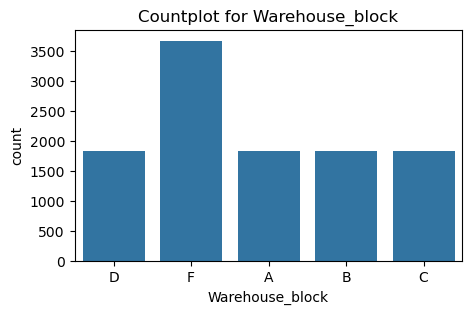

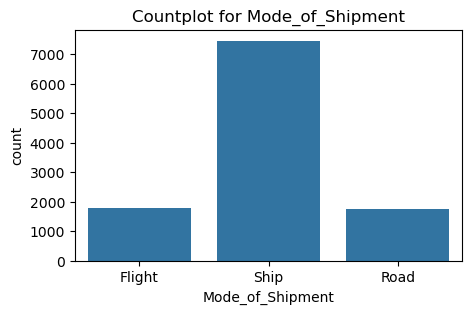

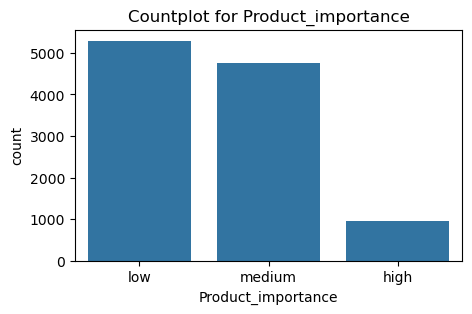

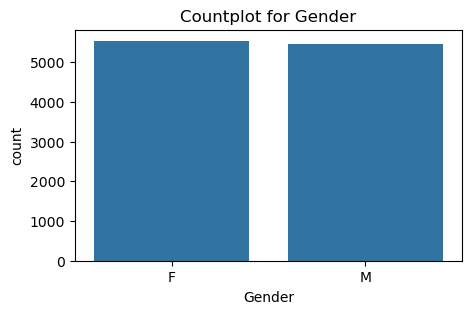

ValueError: could not convert string to float: 'D'

<Figure size 1000x600 with 0 Axes>

In [14]:
# Basic statistics
print(df.describe())

# Visualize categorical columns
for col in df.select_dtypes(include='object').columns:
    plt.figure(figsize=(5,3))
    sns.countplot(data=df, x=col)
    plt.title(f"Countplot for {col}")
    plt.show()

# Correlation heatmap (for numerical features)
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [17]:
# Target column
target_column = 'Reached.on.Time_Y.N'

# Drop ID column from features
X = df.drop(columns=['ID', target_column])
y = df[target_column]

# Verify shapes
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10999, 10)
Target shape: (10999,)


In [19]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Identify numeric and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

# Preprocessing: scale numeric, one-hot encode categorical
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# Apply preprocessing
X_scaled = preprocessor.fit_transform(X)
print("✅ Features encoded and scaled. Shape:", X_scaled.shape)

Numeric columns: ['Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms']
Categorical columns: []
✅ Features encoded and scaled. Shape: (10999, 10)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (8799, 10)
Testing Set: (2200, 10)


In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score


In [22]:
# ------------------------------
# Logistic Regression
# ------------------------------
log_model = LogisticRegression(max_iter=500, class_weight='balanced')
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_proba_log = log_model.predict_proba(X_test)[:,1]


In [23]:
# Evaluation
print("===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log))
print("Classification Report:\n", classification_report(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

===== Logistic Regression =====
Accuracy: 0.6477272727272727
ROC-AUC: 0.7158215778216448
Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.84      0.66       887
           1       0.83      0.51      0.64      1313

    accuracy                           0.65      2200
   macro avg       0.69      0.68      0.65      2200
weighted avg       0.71      0.65      0.65      2200

Confusion Matrix:
 [[749 138]
 [637 676]]


In [24]:
# ------------------------------
# Random Forest
# ------------------------------
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:,1]

In [25]:
# Evaluation
print("\n===== Random Forest =====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


===== Random Forest =====
Accuracy: 0.6568181818181819
ROC-AUC: 0.7356493172515586
Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.70      0.62       887
           1       0.76      0.62      0.68      1313

    accuracy                           0.66      2200
   macro avg       0.66      0.66      0.65      2200
weighted avg       0.68      0.66      0.66      2200

Confusion Matrix:
 [[625 262]
 [493 820]]


In [33]:
# ===============================
# STEP 4: Set Features and Target
# ===============================
target_column = 'Reached.on.Time_Y.N'  # target
X = df.drop(columns=['ID', target_column])  # features
y = df[target_column]

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (10999, 10)
Target shape: (10999,)


In [34]:
# ===============================
# STEP 5: Identify Numeric and Categorical Columns
# ===============================
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns: ['Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms']
Categorical columns: []


In [35]:
# ===============================
# STEP 6: Preprocessing (Scaling + One-Hot Encoding)
# ===============================
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# Fit & transform features
X_processed = preprocessor.fit_transform(X)
print("Processed features shape:", X_processed.shape)

Processed features shape: (10999, 10)


In [36]:
# ===============================
# STEP 7: Train-Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (8799, 10)
Testing set: (2200, 10)


In [37]:
# ===============================
# STEP 8: Train Models
# ===============================

# Logistic Regression
log_model = LogisticRegression(max_iter=500, class_weight='balanced')
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
y_proba_log = log_model.predict_proba(X_test)[:,1]

# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:,1]

In [38]:
# ===============================
# STEP 9: Evaluate Models
# ===============================

print("===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log))
print(classification_report(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

print("\n===== Random Forest =====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

===== Logistic Regression =====
Accuracy: 0.6477272727272727
ROC-AUC: 0.7158215778216448
              precision    recall  f1-score   support

           0       0.54      0.84      0.66       887
           1       0.83      0.51      0.64      1313

    accuracy                           0.65      2200
   macro avg       0.69      0.68      0.65      2200
weighted avg       0.71      0.65      0.65      2200

Confusion Matrix:
 [[749 138]
 [637 676]]

===== Random Forest =====
Accuracy: 0.6568181818181819
ROC-AUC: 0.7356493172515586
              precision    recall  f1-score   support

           0       0.56      0.70      0.62       887
           1       0.76      0.62      0.68      1313

    accuracy                           0.66      2200
   macro avg       0.66      0.66      0.65      2200
weighted avg       0.68      0.66      0.66      2200

Confusion Matrix:
 [[625 262]
 [493 820]]


Total features: 10 Feature names: 10


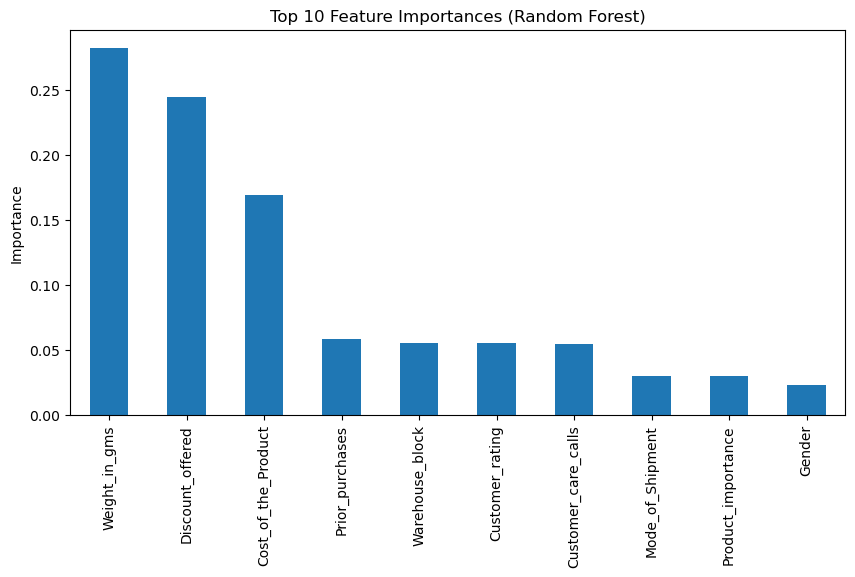

In [40]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Number of features after preprocessing
n_features = X_processed.shape[1]

# Create generic feature names
feature_names = []

# Numeric features: keep original names
feature_names.extend(num_cols)

# Categorical features: create generic names for one-hot encoded columns
for col in cat_cols:
    n_unique = X[col].nunique()
    for i in range(n_unique):
        feature_names.append(f"{col}_{i}")

# Make sure the number of names matches processed features
print("Total features:", n_features, "Feature names:", len(feature_names))

# Feature importances
importances = pd.Series(rf_model.feature_importances_, index=feature_names)

# Plot top 10
importances.sort_values(ascending=False).head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Feature Importances (Random Forest)")
plt.ylabel("Importance")
plt.show()

In [46]:
# Import joblib
import joblib

# Save the trained Random Forest model
joblib.dump(rf_model, "shipment_model_rf.pkl")
print("✅ Random Forest model saved as 'shipment_model_rf.pkl'")


✅ Random Forest model saved as 'shipment_model_rf.pkl'
